In [1]:
import numpy 
import matplotlib.pyplot as plt  
import os 
import pandas as pd 
import numpy as np  


from sklearn.model_selection import train_test_split

np.random.seed(123)  # For reproducibility

In [2]:
import xgboost as xgb   

### Data preparation 

In [3]:
# Load the insurance data , should be in the same directory as this script
insurance_data = pd.read_csv('data/insurance_data_raw.csv')

insurance_data = insurance_data.sample(frac=1).reset_index(drop=True)
# Separate features and target variable
target = insurance_data["claim"].values


insurance_data.head(n=9)


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,56.0,male,56,33.7,NoDisease,4,0,Charleston,74,1,0,HouseKeeper,12949.2
1,56.0,female,66,37.5,NoDisease,2,0,WashingtonDC,82,1,0,CEO,12265.5
2,48.0,male,51,NaN,NoDisease,3,0,Memphis,74,1,0,Farmer,10141.1
3,59.0,female,75,27.8,NoDisease,3,0,Charleston,80,1,1,Dancer,14001.3
4,38.0,female,88,40.6,NoDisease,1,0,Oceanside,72,1,0,Politician,6373.6
5,47.0,male,89,29.8,NoDisease,3,0,Chicago,0,1,1,Technician,9620.3
6,53.0,male,71,29.2,NoDisease,0,0,Boston,78,1,0,Student,10072.1
7,53.0,male,60,36.1,NoDisease,1,0,Cambridge,64,1,1,Lawyer,10085.9
8,41.0,male,95,29.6,NoDisease,5,0,Louisville,62,1,0,ITProfessional,9222.4


In [4]:
from sklearn.preprocessing import LabelEncoder

# Remove 'claim' column
insurance_data_no_claim = insurance_data.drop(columns=['claim'])
# Encode string columns to integer
string_columns = insurance_data_no_claim.select_dtypes(include='object').columns
label_encoders = {}

for col in string_columns:
    le = LabelEncoder()
    insurance_data_no_claim[col] = le.fit_transform(insurance_data_no_claim[col])
    label_encoders[col] = le

insurance_data_no_claim.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title
0,56.0,1,56,33.7,8,4,0,12,74,1,0,23
1,56.0,0,66,37.5,8,2,0,86,82,1,0,9
2,48.0,1,51,NaN,8,3,0,47,74,1,0,17
3,59.0,0,75,27.8,8,3,0,12,80,1,1,12
4,38.0,0,88,40.6,8,1,0,57,72,1,0,31


In [5]:
# How to handle missing values ####
insurance_data_no_claim.isna().sum() 
#get the number of missing values in each column
#insurance_data_no_claim = insurance_data_no_claim.dropna()  # Drop rows with missing values
insurance_data_no_claim = insurance_data_no_claim.fillna(insurance_data_no_claim.mean())  # Fill missing values with column mean


# Receive a summary of the dataframe ####
# insurance_data_no_claim.info() get a summary of the dataframe
# insurance_data_no_claim.describe() get a statistical summary of the dataframe

print(insurance_data_no_claim.isna().sum())


age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
dtype: int64


### Feature engineering  

In [6]:
# Discard not significant features

#if "index" in insurance_data_no_claim.columns or "PatientID" in insurance_data_no_claim.columns:
features = insurance_data_no_claim  #.drop(columns=['index', 'PatientID'])


# Standardize numerical features
features["age"] = (features["age"] - features["age"].mean()) / features["age"].std()
features["bloodpressure"] = (features["bloodpressure"] - features["bloodpressure"].mean()) / features["bloodpressure"].std()
features["bmi"] = (features["bmi"] - features["bmi"].mean()) / features["bmi"].std()

# Normalize to [0,1]
max_target = target.max()

target = target / max_target    
target_ind = target.copy()


# Split the dataset into training, validation, and test sets ####
from sklearn.model_selection import train_test_split

# Split the data into train, validation, and test sets (e.g., 60% train, 20% val, 20% test)

# First split into train and temp (train: 60%, temp: 40%)
X_temp, X_test, y_temp, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

print("Train set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Train set size: (9000, 12)
Validation set size: (3000, 12)
Test set size: (3000, 12)


In [18]:
#features.to_csv("data/insurance_data_mod.csv")

### ML (using sklearn and pytorch)

#### Linear Regression (sklearn)

In [7]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

# Features (insurance_data_no_claim) und Zielvariable (target) verwenden
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Vorhersage für die Trainingsdaten
predictions = lin_reg.predict(X_test)

# Beispiel: Ausgabe der ersten 5 Vorhersagen
print(predictions[:5])
print(y_test[:5] )

from sklearn.metrics import mean_squared_error


# Train Linear Regression on training set
lin_reg_val = LinearRegression()
lin_reg_val.fit(X_train, y_train)

# Predict on validation set
val_predictions = lin_reg_val.predict(X_val)
lin_pred = lin_reg_val.predict(X_test)

# Output first 5 predictions and ground truth
print("Validation predictions:", np.round(val_predictions[:5], 3) )
print("Validation ground truth:",np.round(y_val[:5], 3))

# Calculate MSE for validation set
mse_val = mean_squared_error(y_val, val_predictions)
print("Validation Mean Squared Error 10^3:", mse_val * 10**3)


# Calculate MSE for test set
mse_test = mean_squared_error(y_test, lin_pred)
print("Test Mean Squared Error 10^3:", mse_test * 10**3)

[0.20114327 0.04566398 0.15839916 0.18800565 0.51529929]
[0.18709464 0.02571099 0.16344417 0.18551867 0.36696179]
Validation predictions: [0.158 0.404 0.121 0.213 0.144]
Validation ground truth: [0.135 0.582 0.085 0.166 0.075]
Validation Mean Squared Error 10^3: 8.857497607440104
Test Mean Squared Error 10^3: 9.459707177804036


#### Neural Network (pytorch)

In [8]:
import torch

import torch.nn as nn
import torch.optim as optim
from neural_network import InsuranceRegressor

# Konvertiere die Trainings- und Testdaten in Torch-Tensoren
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


model = InsuranceRegressor(X_train.shape[1])

# Loss und Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 2000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# Vorhersage und Auswertung
model.eval()
with torch.no_grad():
    predictions_torch = model(X_test_tensor).squeeze().numpy()
    mse_torch = ((predictions_torch - y_test)**2).mean()
    print("PyTorch MSE 10^3:", mse_torch * 10**3)

Epoch 0, Loss: 7.824454
Epoch 100, Loss: 0.049467
Epoch 200, Loss: 0.035468
Epoch 300, Loss: 0.031269
Epoch 400, Loss: 0.027845
Epoch 500, Loss: 0.022708
Epoch 600, Loss: 0.015049
Epoch 700, Loss: 0.011455
Epoch 800, Loss: 0.010570
Epoch 900, Loss: 0.010229
Epoch 1000, Loss: 0.010056
Epoch 1100, Loss: 0.009934
Epoch 1200, Loss: 0.009821
Epoch 1300, Loss: 0.009744
Epoch 1400, Loss: 0.009683
Epoch 1500, Loss: 0.009627
Epoch 1600, Loss: 0.009578
Epoch 1700, Loss: 0.009541
Epoch 1800, Loss: 0.009505
Epoch 1900, Loss: 0.009469
PyTorch MSE 10^3: 9.73321767401127


In [9]:
# Early Stopping Parameter
patience = 10
epochs = 2000                   
best_loss = float('inf')

import torch.nn as nn
import torch.optim as optim




model_es = InsuranceRegressor(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model_es.parameters(), lr=0.001)

# Training mit Early Stopping

for epoch in range(epochs):
    model_es.train()
    optimizer.zero_grad()
    outputs = model_es(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # Validierung
    model_es.eval()
    with torch.no_grad():
        val_outputs = model_es(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
    
    # Early Stopping Check
    if val_loss.item() < best_loss:
        best_loss = val_loss.item()
        best_model_state = model_es.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Training Loss: {loss.item():.6f}, Validation Loss: {val_loss.item():.6f}")


# Vorhersage und Auswertung
model.eval()
with torch.no_grad():
    predictions_torch = model(X_test_tensor).squeeze().numpy()
    mse_torch = ((predictions_torch - y_test)**2).mean()
    print("PyTorch MSE 10^3:", mse_torch * 10**3)

Epoch 0, Training Loss: 0.371466, Validation Loss: 0.338054
Epoch 100, Training Loss: 0.036777, Validation Loss: 0.038426
Epoch 200, Training Loss: 0.029953, Validation Loss: 0.031287
Epoch 300, Training Loss: 0.023631, Validation Loss: 0.025380
Epoch 400, Training Loss: 0.016332, Validation Loss: 0.017622
Epoch 500, Training Loss: 0.010865, Validation Loss: 0.011424
Epoch 600, Training Loss: 0.009495, Validation Loss: 0.009774
Epoch 700, Training Loss: 0.008897, Validation Loss: 0.009181
Epoch 800, Training Loss: 0.008396, Validation Loss: 0.008627
Epoch 900, Training Loss: 0.007991, Validation Loss: 0.008205
Epoch 1000, Training Loss: 0.007791, Validation Loss: 0.007972
Epoch 1100, Training Loss: 0.007632, Validation Loss: 0.007771
Epoch 1200, Training Loss: 0.007546, Validation Loss: 0.007651
Epoch 1300, Training Loss: 0.007467, Validation Loss: 0.007549
Epoch 1400, Training Loss: 0.007407, Validation Loss: 0.007458
Epoch 1500, Training Loss: 0.007362, Validation Loss: 0.007406
Epoc

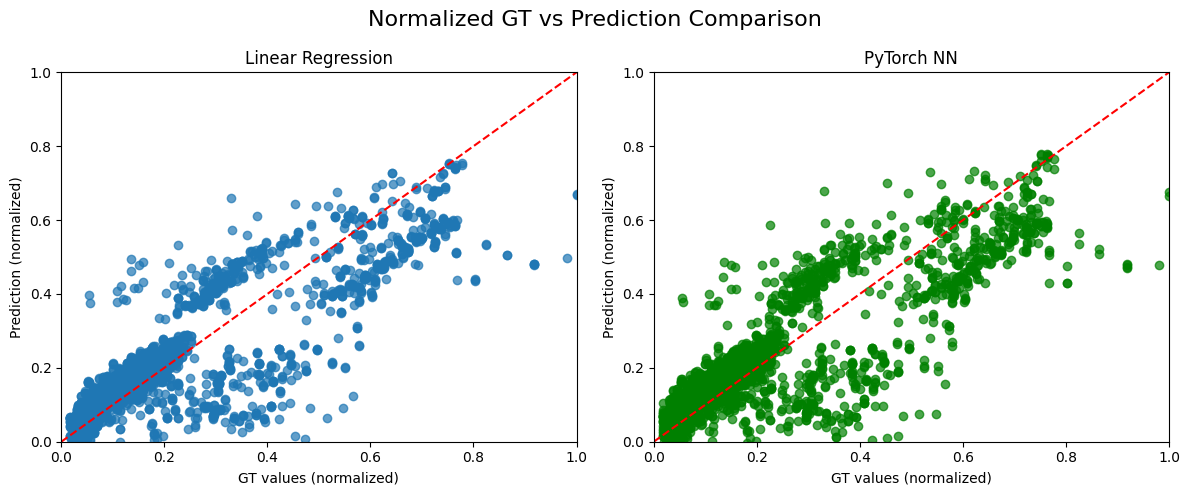

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ideal = np.linspace(0, 1, 10)


fig.suptitle('Normalized GT vs Prediction Comparison', fontsize=16)
# Scatterplot für Linear Regression
axes[0].scatter(y_test, lin_pred, alpha=0.7)
axes[0].plot(ideal, ideal, color="red", linestyle="--")
axes[0].set_title('Linear Regression')
axes[0].set_xlabel('GT values (normalized)')
axes[0].set_ylabel('Prediction (normalized)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Scatterplot für Neural Network (PyTorch)
axes[1].scatter(y_test, predictions_torch, alpha=0.7, color ="green")
axes[1].plot(ideal, ideal, color="red", linestyle="--")
axes[1].set_title('PyTorch NN')
axes[1].set_xlabel('GT values (normalized)')
axes[1].set_ylabel('Prediction (normalized)')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
from scipy.stats import pearsonr, spearmanr
import numpy as np

# y_test: echte Werte
# y_pred: Vorhersagen des Modells

# Metriken
mse = mean_squared_error(y_test, predictions_torch)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions_torch)
median_ae = median_absolute_error(y_test, predictions_torch)
r2 = r2_score(y_test, predictions_torch)

# Korrelationen
pearson_corr, _ = pearsonr(y_test, predictions_torch)
spearman_corr, _ = spearmanr(y_test, predictions_torch)

# Ausgabe
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Median AE: {median_ae:.4f}")
print(f"R²: {r2:.4f}")
print(f"Pearson-Korrelation: {pearson_corr:.4f}")
print(f"Spearman-Korrelation: {spearman_corr:.4f}")


MSE: 0.0097
RMSE: 0.0987
MAE: 0.0676
Median AE: 0.0417
R²: 0.7372
Pearson-Korrelation: 0.8586
Spearman-Korrelation: 0.8336


In [12]:
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr
import numpy as np

# y_test: echte Werte
# y_pred: Vorhersagen des Modells

# Korrelationen
pearson_corr, _ = pearsonr(y_test, lin_pred)
spearman_corr, _ = spearmanr(y_test, lin_pred)
# Ausgabe
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Median AE: {median_ae:.4f}")
print(f"R²: {r2:.4f}")
print(f"Pearson-Korrelation: {pearson_corr:.4f}")
print(f"Spearman-Korrelation: {spearman_corr:.4f}")


MSE: 0.0097
RMSE: 0.0987
MAE: 0.0676
Median AE: 0.0417
R²: 0.7372
Pearson-Korrelation: 0.8631
Spearman-Korrelation: 0.8452


In [13]:
def metrics_summary(matric_dic, pred, gt, method_name=""):
    pearson_corr, _ = pearsonr(gt, pred)
    spearman_corr, _ = spearmanr(gt, pred)
    r2 = r2_score(gt, pred)
    matric_dic[method_name] = [pearson_corr, spearman_corr, r2]
    return matric_dic

metrics_dict = {}

metrics_dict = metrics_summary(metrics_dict, lin_pred, y_test, method_name="Linear Regression")
metrics_dict = metrics_summary(metrics_dict, predictions_torch, y_test, method_name="PyTorch NN")

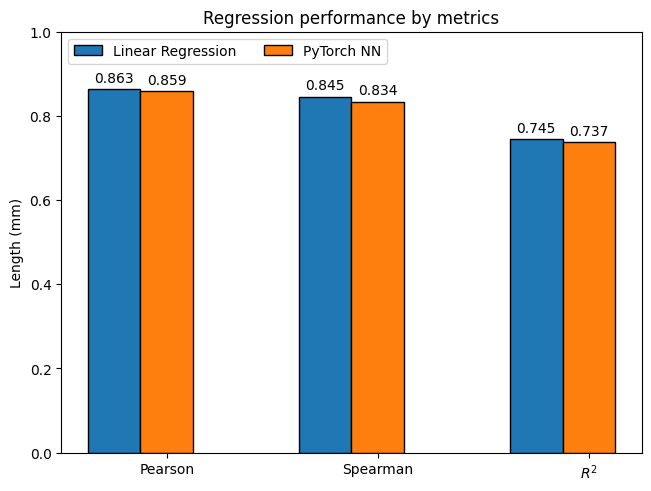

In [14]:
metrics = ("Pearson", "Spearman", "$R^{2}$")

x = np.arange(len(metrics))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, metric in metrics_dict.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, np.round(metric, 3) , width, label=attribute, edgecolor='black')
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Length (mm)')
ax.set_title('Regression performance by metrics')
ax.set_xticks(x + width, metrics)
ax.legend(loc='upper left', ncols=2)
ax.set_ylim(0, 1)

plt.show()

In [ ]:
# import seaborn as sns
#### lool
# # Kombiniere die Features und das Target in einem DataFrame
# pairplot_df = features.copy()
# pairplot_df['target'] = target

# # Erstelle den Pairplot
# sns.pairplot(pairplot_df, hue='target', diag_kind='kde', palette='viridis')

## TODO: Using XAI (SHAP and LIME)

In [15]:
import numpy as np
print(np.__version__)

2.2.0


In [15]:
import shap


c:\Users\brand\anaconda3\envs\insurance\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
explainer = shap.LinearExplainer(lin_reg, X_train)
shap_values = explainer(X_test)
shap.initjs()

C:\Users\brand\AppData\Local\Temp\ipykernel_37284\2940161786.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


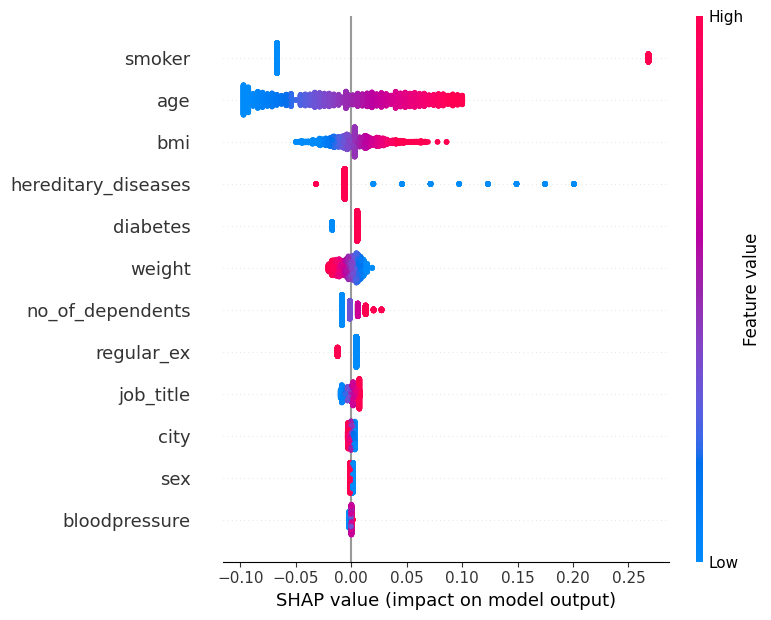

In [17]:
shap.summary_plot(shap_values, X_test)

In [18]:
shap_values

.values =
array([[ 0.07438671, -0.00094214, -0.00184708, ...,  0.00542094,
         0.0045735 ,  0.0067716 ],
       [-0.09291904, -0.00094214,  0.01111489, ..., -0.01716631,
         0.0045735 ,  0.00728074],
       [ 0.05722715, -0.00094214, -0.00184708, ...,  0.00542094,
        -0.0123654 ,  0.00218931],
       ...,
       [ 0.04864736,  0.00135576,  0.0072263 , ...,  0.00542094,
        -0.0123654 , -0.00799354],
       [-0.00477241,  0.00135576, -0.01027236, ...,  0.00542094,
         0.0045735 ,  0.00218931],
       [ 0.0786766 , -0.00094214, -0.00832806, ...,  0.00542094,
         0.0045735 ,  0.00575331]], shape=(3000, 12))

.base_values =
array([0.2109818, 0.2109818, 0.2109818, ..., 0.2109818, 0.2109818,
       0.2109818], shape=(3000,))

.data =
array([[ 1.33426405,  1.        , 66.        , ...,  1.        ,
         0.        , 32.        ],
       [-1.48575263,  1.        , 46.        , ...,  0.        ,
         0.        , 33.        ],
       [ 1.04503157,  1.        ,